# Importing required libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
df = pd.read_csv("Customer Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Replacing blank spaces in the TotalCharges column with 0 as Total Tenure is 0 and no charges are recorded.
# Also changing the data type of TotalCharges column from Object to float

In [25]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Checking Statistical summary for numerical columns

In [31]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# Checking if the customerId column which is supposed to be unique has any duplicate values

In [39]:
df["customerID"].duplicated().sum()


0

# converting 0 and 1 values of senior citizen to yes/no easiere understanding

In [41]:
def conv(value):
    
    if value == 1:
        return "Yes"
    else:
        return "No"
df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

In [46]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


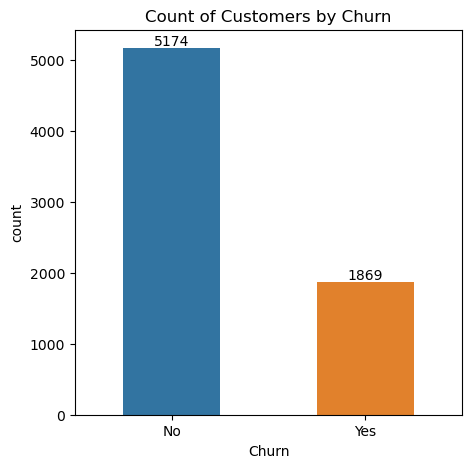

In [187]:
plt.figure(figsize = (5,5))
ax =sns.countplot(x=df["Churn"], width = 0.5)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

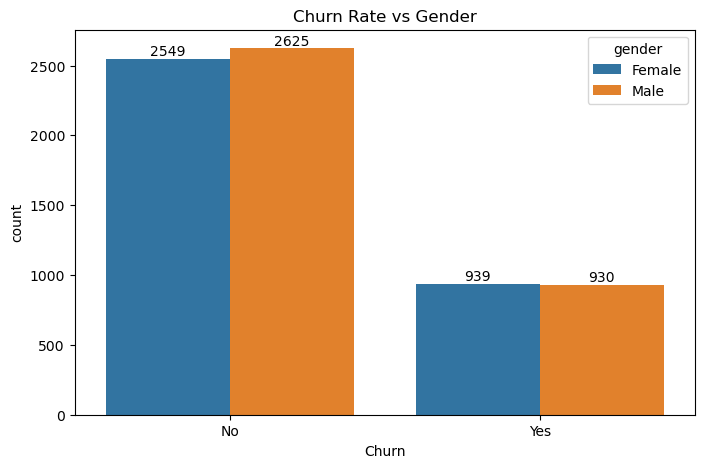

In [78]:
plt.figure(figsize = (8,5))
ax =sns.countplot(x=df["Churn"], hue = df['gender'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churn Rate vs Gender')

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

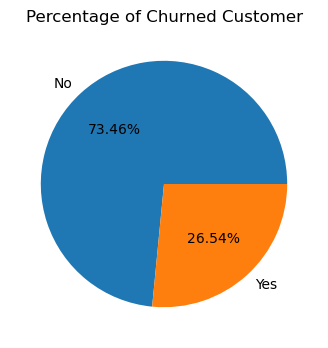

In [77]:
plt.figure(figsize = (5,4))
gb = df.groupby('Churn').agg({'Churn': 'count'})
plt.pie(gb['Churn'], labels = gb.index, autopct = '%1.2f%%' )
plt.title('Percentage of Churned Customer')
plt.show

# from the given pie chart we can conclude that 26.54% of our customers have churned out.

# Exploring the reason behind it

<function matplotlib.pyplot.show(close=None, block=None)>

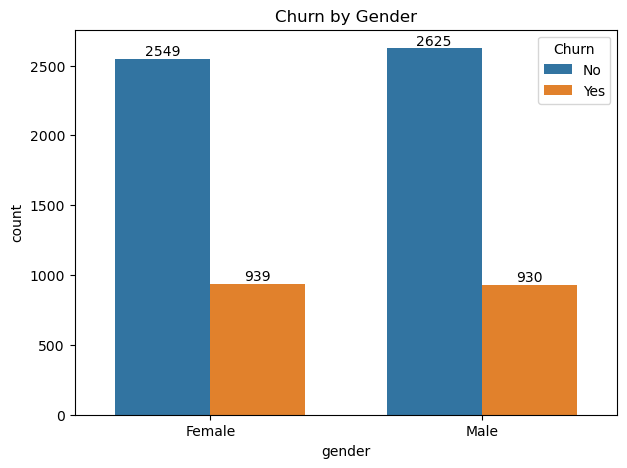

In [94]:
plt.figure(figsize = (7,5))
ax = sns.countplot(x = df['gender'], hue = df['Churn'], width = 0.7)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Gender", fontsize = 12)
plt.show

# Churn rate is not gender specific!

<function matplotlib.pyplot.show(close=None, block=None)>

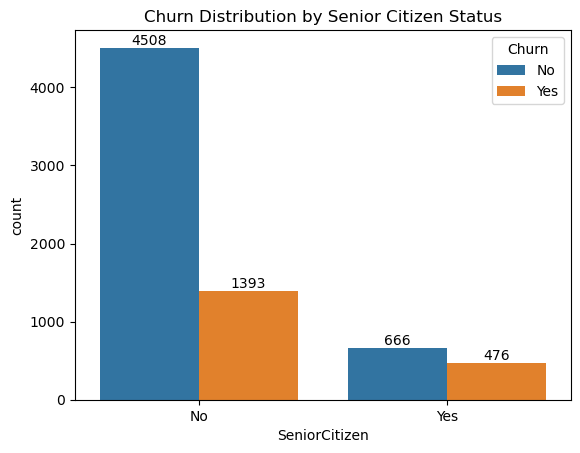

In [121]:
ax= sns.countplot(x = df['SeniorCitizen'], hue = df['Churn'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churn Distribution by Senior Citizen Status')
plt.show

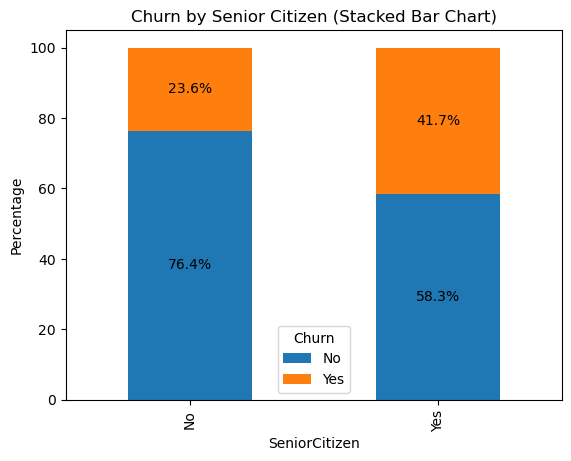

In [133]:
table = pd.crosstab(df['SeniorCitizen'],
                    df['Churn'],
                    normalize='index') * 100

ax = table.plot(kind='bar', stacked=True)

for container in ax.containers:
    ax.bar_label(container,
                 fmt='%.1f%%',
                 label_type='center')
    
plt.ylabel("Percentage")    
plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.show()

# normalized crosstab to convert counts into row-wise percentages and then plotted a stacked bar chart to visualize churn distribution within each senior citizen group.

# comparatively a greater pecentage of people in senior citizen category have churned

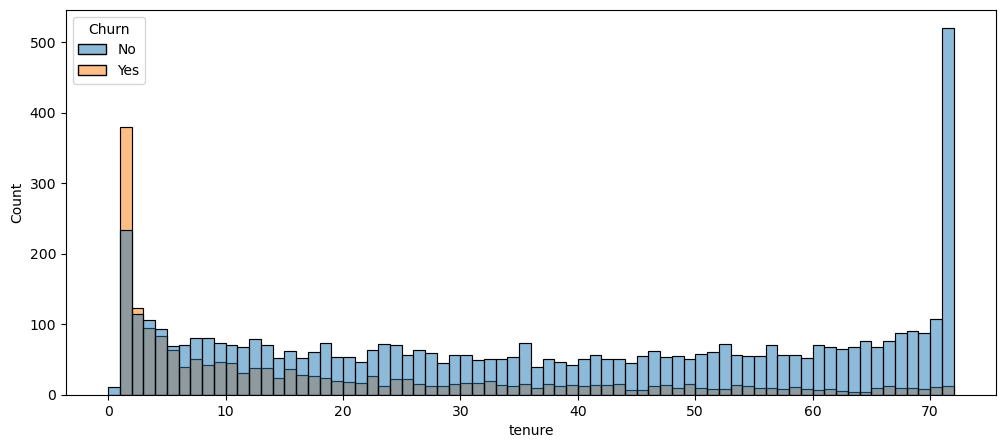

In [130]:
plt.figure(figsize = (12,5))
sns.histplot(x = df['tenure'],hue = df['Churn'], bins = 72)
plt.show()

# people who have used our services for a long time have stayed and people who have used our sevices 1 or 2 months have churned

In [135]:
table1 = pd.crosstab(df['tenure'],
                    df['Churn'])
table1

Churn,No,Yes
tenure,,
0,11,0
1,233,380
2,115,123
3,106,94
4,93,83
...,...,...
68,91,9
69,87,8
70,108,11


<function matplotlib.pyplot.show(close=None, block=None)>

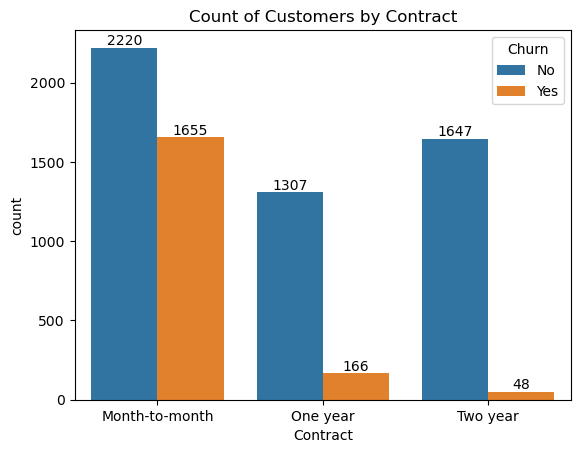

In [139]:
ax = sns.countplot(x = df['Contract'], hue = df['Churn'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customers by Contract")
plt.show

# people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract. 

In [140]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

# Performing analysis on the services columns i.e : 'PhoneService', 'MultipleLines', 'InternetService','OnlineSecurity', 'OnlineBackup', 'DeviceProtection','TechSupport', 'StreamingTV', 'StreamingMovies'

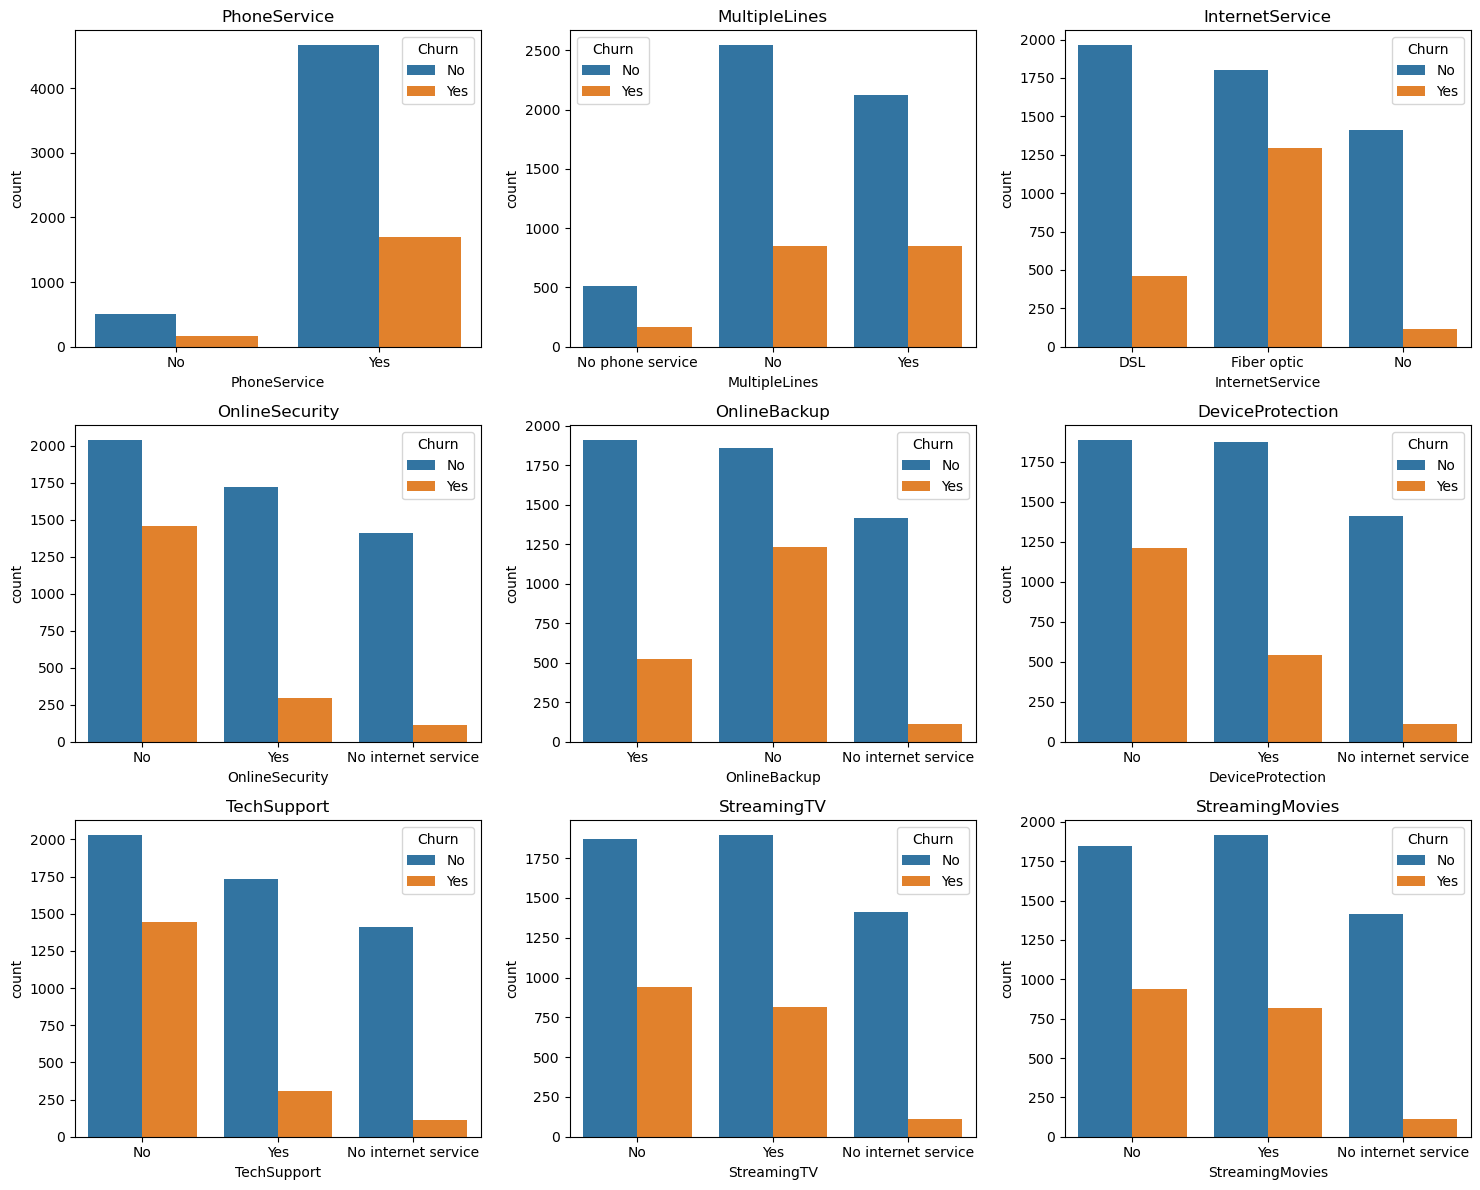

In [146]:
columns = ['PhoneService', 'MultipleLines', 'InternetService',
           'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
           'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(15,12))

axes = axes.flatten()

for i, col in enumerate(columns):

    sns.countplot(x=col,
                  data=df,
                  hue='Churn',
                  ax=axes[i])

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable.

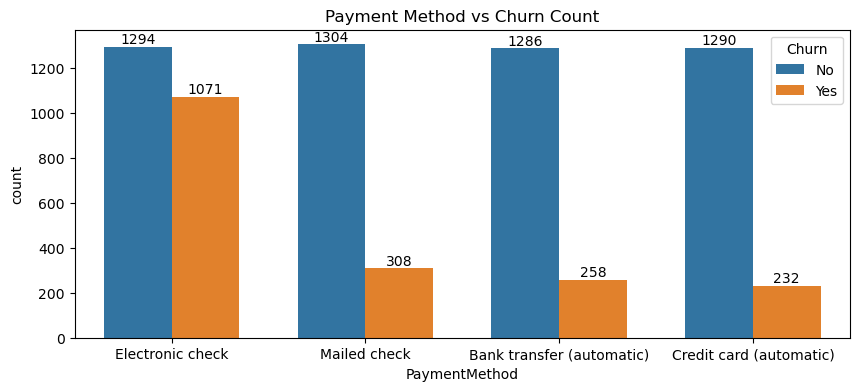

In [160]:
plt.figure(figsize = (10,4))
ax = sns.countplot(x = df['PaymentMethod'], hue = df['Churn'], width= 0.7)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Payment Method vs Churn Count')
plt.show()

# customer is likely to churn when he is using electronic check as a payment method.